# 3D halo power spectrum

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:

from matplotlib.lines import Line2D

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list = palette_tab10

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [5]:
odir = "/cosma/home/dp004/dc-zhan5/nbodykit-ps/ps_data_sphereX_res"

In [10]:

with open(f"{odir}/snap40/mvir/logM/ps-intensity-gal_logM10.5.pickle", "rb") as f:
    Pk_mean_105 = pickle.load(f)
    Pk_gal105 = pickle.load(f)

In [11]:
with open(f"{odir}/snap40/mvir/logM/ps-intensity-gal_logM11.0.pickle", "rb") as f:
    Pk_mean_11 = pickle.load(f)
    Pk_gal11 = pickle.load(f)

In [17]:

with open(f"{odir}/snap40/mvir/ps-intensity-gal_all.pickle", "rb") as f:
    Pk_mean_all = pickle.load(f)
    Pk_gal_all = pickle.load(f)

In [8]:

with open(f"{odir}/snap40/mvir/ps-intensity-gal_all.pickle", "rb") as f:
    Pk_mean10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)

In [7]:
logM_min = 10
logM_max = 11.3

In [20]:
logM_min = 13.5
logM_max = 14.45

In [8]:
arr =  np.round(np.arange(logM_min,logM_max, 0.1),1)

In [9]:
ik = 0

In [10]:
Pks = []
Pk_means = []
shot_list = []
"""
with open(f"{odir}/snap40/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
    Pk_means.append(Pk_mean_gal10)
    Pks.append(Pk_gal10["power"].real[ik])
    shot_list.append(Pk_gal10.attrs["shotnoise"])
"""
for mass in arr:
    
    if logM_min > 13:
        fname = f"{odir}/snap40/mvir/logM/ps-intensity-gal_logM<{mass}.pickle"
    else:
        fname = f"{odir}/snap40/mvir/logM/ps-intensity-gal_logM{mass}.pickle"
    with open(fname, "rb") as f:
        
            Pk_mean1 = pickle.load(f)
            Pk_gal1 = pickle.load(f)
            Pk_means.append(Pk_mean1)
            Pks.append(Pk_gal1["power"].real[ik])
            shot_list.append(Pk_gal1.attrs["shotnoise"])
shot_arr = np.array(shot_list)
Pks_arr = np.array(Pks)

In [11]:
arr_fof = np.round(np.arange(logM_min,logM_max, 0.1),1)

In [12]:
arr_all = np.round(np.arange(logM_min,logM_max, 0.1),1)

In [14]:
Pks_fof = []
Pk_means_fof = []
shot_list_fof = []
"""
with open(f"{odir}/snap40/fof/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
    Pk_means_fof.append(Pk_mean_gal10)
    Pks_fof.append(Pk_gal10["power"].real[ik])
    shot_list_fof.append(Pk_gal10.attrs["shotnoise"])
"""
for mass in arr:
    with open(f"{odir}/snap40/fof/logM/ps-intensity-gal_logM{mass}.pickle", "rb") as f:
        Pk_mean1 = pickle.load(f)
        Pk_gal1 = pickle.load(f)
        Pk_means_fof.append(Pk_mean1)
        Pks_fof.append(Pk_gal1["power"].real[ik])
        shot_list_fof.append(Pk_gal1.attrs["shotnoise"])
shot_fof_arr = np.array(shot_list_fof)
Pks_fof_arr = np.array(Pks_fof)

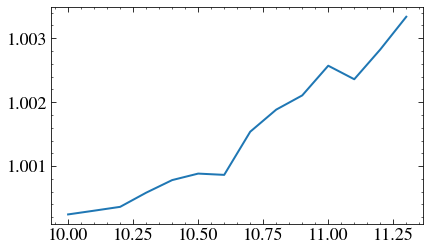

In [20]:
plt.plot(arr_all, Pks/Pks_fof_arr)

In [24]:
Pk_means_fof/np.array(Pk_means)

array([1.00023597, 1.00033402, 1.00044643, 1.00057431, 1.0007354 ,
       1.00091737, 1.00113968, 1.0014407 , 1.00173465, 1.00212154,
       1.00238846, 1.00292915, 1.00352178, 1.00393585])

In [25]:
shot_arr/shot_fof_arr

array([1.00047212, 1.00066786, 1.00089256, 1.00114816, 1.00147007,
       1.0018338 , 1.0022778 , 1.00287874, 1.00346579, 1.00423907,
       1.00477741, 1.00586905, 1.0070806 , 1.0079929 ])

In [45]:
shot_arr[iend]/Pk_gal_all.attrs["shotnoise"]

1.2314329376378954

In [48]:
iend = 6
print(arr_all[iend])
print((Pks[iend])/(Pk_gal_all["power"].real[ik]))

10.6
1.0092410979206967


In [44]:
#iend = 10
print(arr_all[iend])
print(np.array(Pk_means)[iend]/np.array(Pk_mean_all))

11.3
0.8993055533677295


Text(0, 0.5, '$\\rm P(k)/P(k)_{TNG\\ all}$')

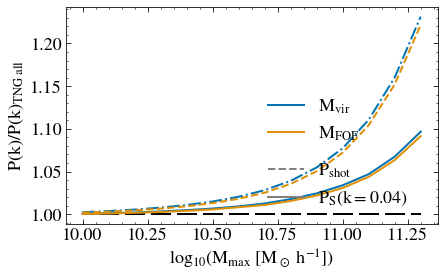

In [18]:
#plt.plot(arr, Pks/Pk_gal_all["power"].real[0], label=r"$\rm P_{S} (k=0.04)$")

plt.plot(arr_all, len(arr_all)*[1], linestyle=(5, (10, 3)), color="k")
plt.plot(arr_all, (Pks)/(Pk_gal_all["power"].real[ik]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[0])
plt.plot(arr_all, np.array(shot_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashdot", label=r"P$_{\rm shot}$", c=color_list[0])
plt.plot(arr_all, (Pks_fof-shot_fof_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[1])
plt.plot(arr_all, np.array(shot_fof_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashed", label=r"P$_{\rm shot}$", c=color_list[1])

label_list = [r"$\rm M_{vir}$", r"$\rm M_{FOF}$"]
solid_lines=[]
for i in range(2):
    solid_line = Line2D([],[],color=color_list[i], linestyle="solid", label=label_list[i])
    solid_lines.append(solid_line)
bbox_to_anchor_grey = (0.5,0)
bbox_to_anchor_color = (0.5,0.3)
legend_fontsize=18
first_legend = plt.legend(handles=solid_lines,fontsize=legend_fontsize, frameon=False, bbox_to_anchor=bbox_to_anchor_color, loc="lower left")
ax = plt.gca().add_artist(first_legend)
shotnoise_ps_leg = Line2D([],[],color="gray", linestyle="dashed", label=r"P$_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color="gray",  label=r"$\rm P_{ S}(k=0.04)$")
leg_list = [shotnoise_ps_leg, shotnoise_subtracted_ps_leg]
plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="lower left", fontsize=legend_fontsize, frameon=False)

plt.xlabel('log$_{10}$(M$_\mathrm{max}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel(r"$\rm P(k)/P(k)_{TNG\ all}$")

#plt.savefig("figures2/max_masses.pdf", format="pdf", bbox_inches="tight")

In [560]:
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

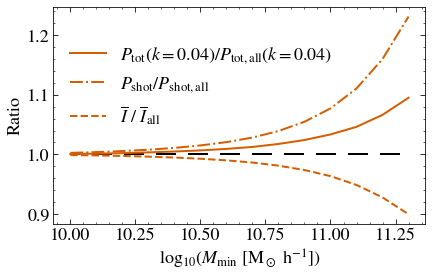

In [177]:
from matplotlib.patches import Rectangle
fig,ax = plt.subplots()
linewidth1=1
plt.plot([arr_all[0],arr_all[-1]], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")
#plt.plot(arr, Pks/Pk_gal_all["power"].real[0], label=r"$\rm P_{S} (k=0.04)$")
plt.plot(arr_all, (Pks-shot_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), linestyle="solid", label=r"$P_{\mathrm{clus}} (k=0.04)$", c=color_list[3
                                                                                                                                          ])
plt.plot(arr_all, np.array(shot_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashdot", label=r"P$_{\rm shot}$", c=color_list[3])
#plt.plot(arr_all, (Pks_fof-shot_fof_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[1])
#plt.plot(arr_all, np.array(shot_fof_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashed", label=r"P$_{\rm shot}$", c=color_list[1])

label_list = [r"$M_{\mathrm{vir}} > M_{\mathrm{min}}$"]
solid_lines=[]
for i in range(1):
    solid_line = Line2D([],[],color=color_list[i], linestyle="solid", label=label_list[i])
    solid_lines.append(solid_line)

legend_fontsize=18
first_legend = plt.legend(handles=solid_lines,fontsize=legend_fontsize, frameon=False)
#ax1 = plt.gca().add_artist(first_legend)
shotnoise_ps_leg = Line2D([],[],color=color_list[3], linestyle="dashdot", label=r"$P_{\rm shot}/ P_{\rm shot, all}$")
tot_ps_leg = Line2D([],[],color=color_list[3], linestyle="solid",label=r"$P_{\rm tot}(k=0.04)/P_{\rm tot, all}(k=0.04)$")
intensity_leg = Line2D([],[],color=color_list[3], linestyle="dashed",label=r"$\overline{I}\ /\ \overline{I}_{\rm all}$")

bbox_to_anchor_grey=(0,0.9)

leg_list = [tot_ps_leg, shotnoise_ps_leg, intensity_leg ]
plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="upper left",fontsize=legend_fontsize, frameon=False)

plt.xlabel('log$_{10}$($M_\mathrm{min}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel("Ratio")
#plt.ylabel(r"$M > M_{\rm min}/{M > 10^8}$M$_\odot$ h$^{-1}$")
#ax.add_patch(Rectangle((10, 1), 0.5, 0.01, fill=False))
"""
# inset axes....
x1, x2, y1, y2 = 10, 10.6, 1, 1.01  # subregion of the original image
axins = ax.inset_axes(
    [0.1, 0.4, 0.6, 0.6],
    xlim=(x1, x2), ylim=(y1, y2))
axins.plot(arr_all,(Pks-shot_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]))

ax.indicate_inset_zoom(axins, edgecolor="black")
"""
#ax.tick_params(length=5)

ax.plot(arr_all, np.array(Pk_means)/Pk_mean_all, linestyle="dashed", color=color_list[3])
#plt.savefig("../figures/min_masses.pdf", format="pdf", bbox_inches="tight")

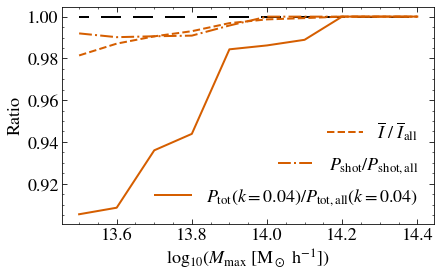

In [28]:
from matplotlib.patches import Rectangle
fig,ax = plt.subplots()
linewidth1=1
plt.plot([arr_all[0],arr_all[-1]], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")
#plt.plot(arr, Pks/Pk_gal_all["power"].real[0], label=r"$\rm P_{S} (k=0.04)$")
plt.plot(arr_all, (Pks-shot_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), linestyle="solid", label=r"$P_{\mathrm{clus}} (k=0.04)$", c=color_list[3
                                                                                                                                          ])
plt.plot(arr_all, np.array(shot_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashdot", label=r"P$_{\rm shot}$", c=color_list[3])
#plt.plot(arr_all, (Pks_fof-shot_fof_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[1])
#plt.plot(arr_all, np.array(shot_fof_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashed", label=r"P$_{\rm shot}$", c=color_list[1])

label_list = [r"$M_{\mathrm{vir}} > M_{\mathrm{min}}$"]
solid_lines=[]
for i in range(1):
    solid_line = Line2D([],[],color=color_list[i], linestyle="solid", label=label_list[i])
    solid_lines.append(solid_line)

legend_fontsize=18
first_legend = plt.legend(handles=solid_lines,fontsize=legend_fontsize, frameon=False)
#ax1 = plt.gca().add_artist(first_legend)
shotnoise_ps_leg = Line2D([],[],color=color_list[3], linestyle="dashdot", label=r"$P_{\rm shot}/ P_{\rm shot, all}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color_list[3], linestyle="solid",label=r"$P_{\rm tot}(k=0.04)/P_{\rm tot, all}(k=0.04)$")
intensity_leg = Line2D([],[],color=color_list[3], linestyle="dashed",label=r"$\overline{I}\ /\ \overline{I}_{\rm all}$")

ax = plt.gca()
leg = ax.legend(handles=[intensity_leg],loc = "lower right", bbox_to_anchor=(1,0.3))
ax.add_artist(leg)

bbox_to_anchor_grey = (1,0.15)
leg_list = [shotnoise_ps_leg ]
leg1 = plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="lower right",fontsize=legend_fontsize, frameon=False)
ax.add_artist(leg1)
bbox_to_anchor_grey = (1,0)
leg_list = [shotnoise_subtracted_ps_leg ]
plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="lower right",fontsize=legend_fontsize, frameon=False)

plt.xlabel('log$_{10}$($M_\mathrm{max}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel("Ratio")
#plt.ylabel(r"$M > M_{\rm min}/{M > 10^8}$M$_\odot$ h$^{-1}$")
#ax.add_patch(Rectangle((10, 1), 0.5, 0.01, fill=False))
"""
# inset axes....
x1, x2, y1, y2 = 10, 10.6, 1, 1.01  # subregion of the original image
axins = ax.inset_axes(
    [0.1, 0.4, 0.6, 0.6],
    xlim=(x1, x2), ylim=(y1, y2))
axins.plot(arr_all,(Pks-shot_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]))

ax.indicate_inset_zoom(axins, edgecolor="black")
"""
#ax.tick_params(length=5)

ax.plot(arr_all, np.array(Pk_means)/Pk_mean_all, linestyle="dashed", color=color_list[3])
#plt.savefig("../figures/max_masses.pdf", format="pdf", bbox_inches="tight")

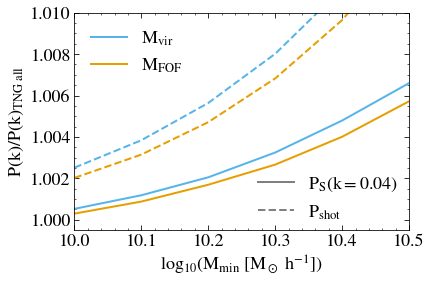

In [561]:
linewidth = 2
plt.plot(arr_all, (Pks-shot_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[0], linewidth=linewidth)
plt.plot(arr_all, np.array(shot_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashed", label=r"P$_{\rm shot}$", c=color_list[0])
plt.plot(arr_all, (Pks_fof-shot_fof_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[1])
plt.plot(arr_all, np.array(shot_fof_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashed", label=r"P$_{\rm shot}$", c=color_list[1])
plt.xlim(10,10.5)
plt.ylim(0.9995,1.01)
plt.minorticks_on()
plt.xlabel('log$_{10}$(M$_\mathrm{min}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel(r"$\rm P(k)/P(k)_{TNG\ all}$")


label_list = [r"$\rm M_{vir}$", r"$\rm M_{FOF}$"]
solid_lines=[]
for i in range(2):
    solid_line = Line2D([],[],color=color_list[i], linestyle="solid", label=label_list[i])
    solid_lines.append(solid_line)
bbox_to_anchor_grey = (0.5,0.33)
legend_fontsize=18
first_legend = plt.legend(handles=solid_lines,fontsize=legend_fontsize, frameon=False)
ax1 = plt.gca().add_artist(first_legend)
shotnoise_ps_leg = Line2D([],[],color="gray", linestyle="dashed", label=r"P$_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color="gray", label=r"$\rm P_{ S}(k=0.04)$")
leg_list = [shotnoise_subtracted_ps_leg, shotnoise_ps_leg]
plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="upper left", fontsize=legend_fontsize, frameon=False)
plt.savefig("figures2/min_masses_zoomed.pdf", format="pdf", bbox_inches="tight")


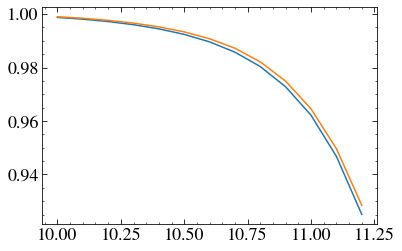

In [553]:
plt.plot(arr_all, np.array(Pk_means)/Pk_mean_all)
plt.plot(arr_all, np.array(Pk_means_fof)/Pk_mean_all)


In [36]:
print(Pk_mean_all)
print(Pk_mean_gal10)
print(Pk_mean_105)

12.871739713503061
12.855563459906872
12.773752621902833


In [59]:
interp="tsc"
Pk_shuffled_list = []
names_list = []
seed_i = 1
seed_f = 9
n_seed = seed_f - seed_i

power_list = []
odir = "ps_data"
snapnum=40
for seed in range(seed_i,seed_f):
    fname = f"{odir}/snap{snapnum}/shuffled/group/polyfit/ps-intensity-group-logM10_dlogM0.1_seed{seed}.pickle"
    with open(fname, "rb") as f:
        Pk_mean_gal_shuffled = pickle.load(f)
        #print("mean", Pk_mean_cent_shuffled)
        Pk_gal_shuffled = pickle.load(f)
        print(Pk_mean_gal_shuffled)
        power_list.append(Pk_gal_shuffled)
        
        #print("shotnoise", Pk_cent_shuffled.attrs["shotnoise"])
        Pk_shuffled_list.append(Pk_gal_shuffled)
        names_list.append(f"seed{seed}")

power_arr = np.array(power_list)


12.870028058594178
12.866583478727867
12.874466244228937
12.872212054142935
12.875102290975134
12.872073382669818
12.869196961784258
12.87260747509763


In [37]:
interp="tsc"
Pk_shuffled_list = []
names_list = []
seed_i = 1
seed_f = 9
n_seed = seed_f - seed_i

power_list = []
odir = "ps_data"
snapnum=40
for seed in range(seed_i,seed_f):
    fname = f"{odir}/snap{snapnum}/shuffled/cent/polyfit/ps-intensity-gal-logM10_dlogM0.1_seed{seed}.pickle"
    with open(fname, "rb") as f:
        Pk_mean_gal_shuffled = pickle.load(f)
        #print("mean", Pk_mean_cent_shuffled)
        Pk_gal_shuffled = pickle.load(f)
        print(Pk_mean_gal_shuffled)
        power_list.append(Pk_gal_shuffled)
        
        #print("shotnoise", Pk_cent_shuffled.attrs["shotnoise"])
        Pk_shuffled_list.append(Pk_gal_shuffled)
        names_list.append(f"seed{seed}")

power_arr = np.array(power_list)


9.298457719179893
9.307192229030123
9.30234206844252
9.299338867367831
9.307840901751781
9.305126657831117
9.306235161416302
9.303941588296402


In [272]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


344
shotnoise:  7.882393312818058
shotnoise:  7.882393312818058
0.011861365315160927 0.011828657988729131
0.011444577207009008 0.011411869880577212
[1.22362468 1.22492175 1.22621479 1.22750248 1.22878562 1.23006629
 1.23134281 1.23261514 1.23388477 1.23515074] [0.4127171435006387, 0.38818522322237325, 0.3776027924520493, 0.2734762970726859, 0.37584808018141, 0.2122988559774097, 0.23131469576174649, 0.05424362677644881, 0.13634599009263926, 0.14665713827504304]


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1320: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


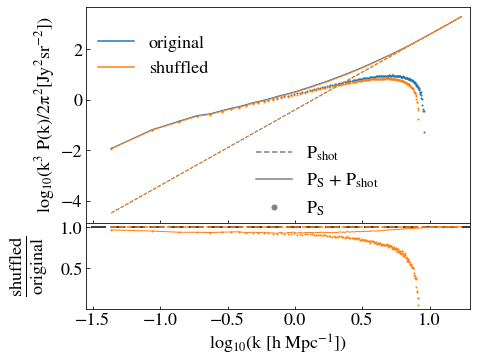

In [13]:
fig,solid_leg = ps.compare_ps_plot([Pk_orig, Pk_shuffled], [r"original", r"shuffled"],  dim=3, residuals_only=False, bbox_to_anchor_grey=(0.4,-0.05), bbox_to_anchor_color=(-0.01,0.6), color_legend=True, ncore=1, return_solid_leg=True, xlim=(-1.55, 1.3), ratio_fontsize=26,  var=True)#, marker_size=1, linewidth=1)
plt.savefig("figures2/mvir_vs_mfof_logM10.pdf", format="pdf", bbox_inches="tight")

344
shotnoise:  134.30755917292575
shotnoise:  136.3740204110012
shotnoise:  134.64551712053182
shotnoise:  145.03438832759022
0.04400589489614298 0.04344859700376513
0.04430132132330441 0.04373544882425697
0.04403021785321751 0.04347151763283166
0.045496348052730506 0.04489454008722941
[1.22362468 1.22492175 1.22621479 1.22750248 1.22878562 1.23006629
 1.23134281 1.23261514 1.23388477 1.23515074] [1.0154156095125386, 1.0154543749189755, 1.0154098767734707, 1.015433423262854, 1.0154482328266374, 1.0154420851557673, 1.0154186696831702, 1.0154238480359588, 1.0154166735435555, 1.0154310816230272]
[1.22362468 1.22492175 1.22621479 1.22750248 1.22878562 1.23006629
 1.23134281 1.23261514 1.23388477 1.23515074] [1.0025422593370772, 1.002547904923122, 1.0025475123849859, 1.002545599046489, 1.0025554972592055, 1.0025466731666046, 1.0025458893711319, 1.0025480928454529, 1.0025503087324812, 1.0025482213830788]
[1.22362468 1.22492175 1.22621479 1.22750248 1.22878562 1.23006629
 1.23134281 1.232615

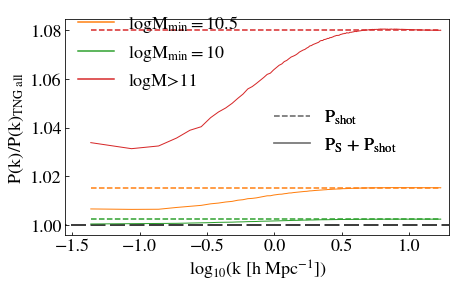

In [40]:
fig,solid_leg = ps.compare_ps_plot([Pk_gal_all, Pk_gal105,Pk_gal10, Pk_gal11], ["logM > 8", r"$ \rm logM_{min} = 10.5$", r"$ \rm logM_{min} = 10$", "logM>11"], ratio_ylabel_list = ["TNG\ all", ""], dim =3, residuals_only=True, bbox_to_anchor_grey=(0.5,0.3), bbox_to_anchor_color=(-0.01,0.6), color_legend=True, shotnoise_subtracted_ps = False, ncore=1, return_solid_leg=True, xlim=(-1.55, 1.3))#, ylim2=(0.95,1.07))#, marker_size=1, linewidth=1)

#ps.compare_ps_plot([Pk_gal_Nmesh4_interlaced, Pk_gal_tsc_not_interlaced, Pk_gal_tsc_interlaced],  labels=["Nmesh x 4", "No Interlacing", "Interlacing"], ratio_ylabel_list=["Nmesh \\times 2", " "], color_legend=True, residuals_only=True, total_ps=False, shotnoise_ps=False, xlim=(-1.6,1.9), bbox_to_anchor_grey=(0.37,0.7), bbox_to_anchor_color=(0.1,0.5), ncore=1, nyquist_list=[nyquist1], ylim2=(0.989,1.1))
Nmesh = 2247
boxsize = 204.9275
k_ny = np.pi * Nmesh / boxsize
log_k_ny = np.log10(k_ny/2)
#plt.axvline(x=log_k_ny, c='black', linestyle="dotted")
#plt.yticks([0,1,2])
#plt.savefig("figures2/tsc_interlace_vs_not.pdf", format="pdf", bbox_inches="tight")
ax = fig.axes[0]

#empty_leg = Line2D([0], [0],  lw=4, color="white")
#solid_leg.insert(1, empty_leg)

#ax.legend(handles=solid_leg[1:], loc='upper center', bbox_to_anchor=(0.5, 1.2),
 #         fancybox=True, shadow=True, ncol=2)

#plt.savefig("figures2/min_mass_ps_ratio_mvir.pdf", format="pdf", bbox_inches="tight")

In [60]:
Pk_list = [Pk_group10]
Pk_list.extend(power_list)

In [4]:
fig,solid_leg = ps.compare_ps_plot(Pk_gal10)#, ratio_ylabel_list=["TNG", "Shuffled"], residuals_only=False, bbox_to_anchor_grey=(0.5,0.5), bbox_to_anchor_color=(0.1,0.55), color_legend=False, ncore=1, return_solid_leg=True, xlim=(-1.55, 1.3), ylim2=(0.88,1.05))# ylim1=(0.9,1.1))

plt.savefig("figures2/shuffled_minus_polyfit_seeds1-9.pdf", format="pdf", bbox_inches="tight")

TypeError: list indices must be integers or slices, not str

In [62]:
Pk_gals_arr = np.array(Pk_gals)

In [176]:
Pk_list = [Pk_gal10]

In [177]:
Pk_list.extend(Pk_gals)

344
shotnoise:  267.7301748422947
shotnoise:  267.97399738052263
0.04401099688201283 0.042900073095709354
0.039587426449618 0.03847549094225053
[1.22362468 1.22492175 1.22621479 1.22750248 1.22878562 1.23006629
 1.23134281 1.23261514 1.23388477 1.23515074] [0.12068730126357037, 1.0973249213980805, 1.1862632816582055, 0.08684031555968823, 0.2633831888627799, 0.48186698384515614, 2.119278783198467, 0.5002795890525661, 2.016863265781695, 0.7789656633015254]


/cosma/home/dp004/dc-zhan5/MyHaloPS.py:1320: RuntimeWarning: invalid value encountered in log10
  y3 = np.log10(y)


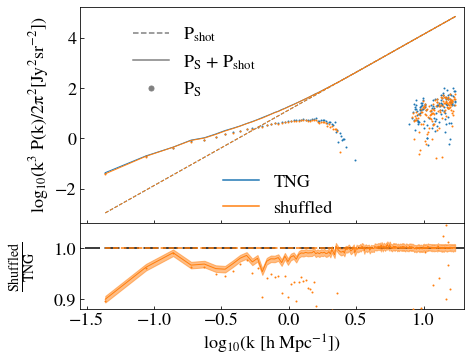

In [62]:
ps.compare_ps_plot(Pk_list, labels=["TNG", "shuffled"], ratio_ylabel_list=["TNG", "Shuffled"],ncore=1, var=True, color_legend=True, mean_of_seeds=True, bbox_to_anchor_color=(0.7,0.3), bbox_to_anchor_grey=(0.5,0.5), ylim2=(0.88,1.05))
plt.savefig("figures2/shuffled_minus_polyfit_seeds1-9_mean.pdf", format="pdf", bbox_inches="tight")


In [32]:
fig,solid_leg = ps.compare_ps_plot([Pk_gal_all100, Pk_gal105, Pk_gal10], ["TNG300-1", "logM > 10.5", "logM > 10"], residuals_only=True, bbox_to_anchor_grey=(0.6,0.3), bbox_to_anchor_color=(0,0.55), color_legend=False, ncore=1, return_solid_leg=True, xlim=(-1.55, 1.3))# ylim1=(0.9,1.1))
#ps.compare_ps_plot([Pk_gal_Nmesh4_interlaced, Pk_gal_tsc_not_interlaced, Pk_gal_tsc_interlaced],  labels=["Nmesh x 4", "No Interlacing", "Interlacing"], ratio_ylabel_list=["Nmesh \\times 2", " "], color_legend=True, residuals_only=True, total_ps=False, shotnoise_ps=False, xlim=(-1.6,1.9), bbox_to_anchor_grey=(0.37,0.7), bbox_to_anchor_color=(0.1,0.5), ncore=1, nyquist_list=[nyquist1], ylim2=(0.989,1.1))
Nmesh = 2247
boxsize = 204.9275
k_ny = np.pi * Nmesh / boxsize
log_k_ny = np.log10(k_ny/2)
#plt.axvline(x=log_k_ny, c='black', linestyle="dotted")
#plt.yticks(np.arange(0.7, 1.3, 0.1))
#plt.savefig("figures2/tsc_interlace_vs_not.pdf", format="pdf", bbox_inches="tight")
ax = fig.axes[0]

#empty_leg = Line2D([0], [0],  lw=4, color="white")
#solid_leg.insert(1, empty_leg)

ax.legend(handles=solid_leg[1:], loc='upper center', bbox_to_anchor=(0.5, 1.2),
          fancybox=True, shadow=True, ncol=2)

#plt.savefig("figures2/logM10.5_cent_vs_sat.pdf", format="pdf", bbox_inches="tight")

NameError: name 'Pk_gal_all100' is not defined